### Trees models for hse nlp project, Dmitriy Lyalin.

In [1]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from catboost import CatBoostClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df_train = pd.read_parquet('/kaggle/input/hse-nlp-data-for-baseline/df_train.pq')
df_test = pd.read_parquet('/kaggle/input/hse-nlp-data-for-baseline/df_test.pq')

In [3]:
df_train.shape, df_test.shape

((100, 39), (51, 39))

In [4]:
df_train.head(2)

,author,text_,cnt_sent,text_len,text,text_len2,words_cnt,wrds_sent_cnt,cnt_words_unique,unwords_words,...,cnt_punct_frq,lex_div,tfidf_keywords,pos_frq,pos_cnt,ent_frq,ent_cnt,uchars_frq,uchars_cnt,fk_score
0,William_Shakespeare,THE LIFE AND DEATH OF KING RICHARD III by Will...,3219,174276,THE LIFE AND DEATH OF KING RICHARD III by Will...,164529,31029,9.639329,4844,0.156112,...,"{'!': 353, '""': 62.0, '#': None, '$': None, '%...",0.156095,gloster,"{'CC': 1200, 'CD': 88, 'DT': 2026, 'EX': 28, '...",33,"{'CARDINAL': 70, 'DATE': 78, 'EVENT': 0, 'FAC'...",14,"{'A': 1478, 'B': 606, 'C': 850, 'D': 562, 'E':...",52,6.0
1,William_Faulkner,"Absalom, Absalom! William Faulkner —1— From a ...",3351,721321,Absalom Absalom William Faulkner —— From a lit...,704116,133926,39.965980,9632,0.071920,...,"{'!': 91, '""': 803.0, '#': None, '$': 1.0, '%'...",0.071499,sutpen,"{'CC': 8474, 'CD': 1154, 'DT': 12430, 'EX': 31...",33,"{'CARDINAL': 652, 'DATE': 771, 'EVENT': 12, 'F...",17,"{'A': 432, 'B': 702, 'C': 536, 'D': 119, 'E': ...",51,16.8


In [5]:
df_test.head(2)

,author,text_,cnt_sent,text_len,text,text_len2,words_cnt,wrds_sent_cnt,cnt_words_unique,unwords_words,...,cnt_punct_frq,lex_div,tfidf_keywords,pos_frq,pos_cnt,ent_frq,ent_cnt,uchars_frq,uchars_cnt,fk_score
0,Aesop,\r\n\r\n[Illustration]\r\n\r\n\r\n\r\n\r\nThe ...,772,80671,\r\n\r\nIllustration\r\n\r\n\r\n\r\n\r\nThe Fa...,78690,13600,17.616580,3882,0.285441,...,"{'!': 17, '""': None, '#': None, '$': None, '%'...",0.207706,None,"{'CC': 783, 'CD': 111, 'DT': 1960, 'EX': 19, '...",33,"{'CARDINAL': 78, 'DATE': 52, 'EVENT': 1, 'FAC'...",16,"{'A': 234, 'B': 170, 'C': 105, 'D': 62, 'E': 6...",50,6.4
1,Agatha_Christie,\r\n\r\n\r\n\r\nProduced by an anonymous Proje...,5189,304491,\r\n\r\n\r\n\r\nProduced by an anonymous Proje...,294515,47474,9.148969,11105,0.233918,...,"{'!': 414, '""': None, '#': None, '$': None, '%...",0.150728,None,"{'CC': 1652, 'CD': 370, 'DT': 5360, 'EX': 173,...",34,"{'CARDINAL': 224, 'DATE': 141, 'EVENT': 60, 'F...",17,"{'A': 598, 'B': 351, 'C': 263, 'D': 223, 'E': ...",52,4.2


Проверим, одинаковые ли у нас колонки в трейне и тесте.

In [6]:
set(df_train.columns) - set(df_test.columns)

set()

In [7]:
set(df_test.columns) - set(df_train.columns)

set()

In [8]:
df_train.columns

Index(['author', 'text_', 'cnt_sent', 'text_len', 'text', 'text_len2',
       'words_cnt', 'wrds_sent_cnt', 'cnt_words_unique', 'unwords_words',
       'median_word_length', 'mean_word_length', 'max_word_length',
       'words_symbols', 'words_dots', 'words_commas', 'words_excls',
       'words_questions', 'words_semicolons', 'words_colons', 'words_dashs',
       'words_aposts', 'words_ellipsis', 'words_quots', 'cnt_adv_freq',
       'cnt_swadesh_freq', 'cnt_word_eng', 'prc_wrds_not_eng', 'uniq_word_cnt',
       'cnt_punct_frq', 'lex_div', 'tfidf_keywords', 'pos_frq', 'pos_cnt',
       'ent_frq', 'ent_cnt', 'uchars_frq', 'uchars_cnt', 'fk_score'],
      dtype='object')

In [9]:
pd.set_option('display.max_columns', None)

In [10]:
df_train.head(2)

,author,text_,cnt_sent,text_len,text,text_len2,words_cnt,wrds_sent_cnt,cnt_words_unique,unwords_words,median_word_length,mean_word_length,max_word_length,words_symbols,words_dots,words_commas,words_excls,words_questions,words_semicolons,words_colons,words_dashs,words_aposts,words_ellipsis,words_quots,cnt_adv_freq,cnt_swadesh_freq,cnt_word_eng,prc_wrds_not_eng,uniq_word_cnt,cnt_punct_frq,lex_div,tfidf_keywords,pos_frq,pos_cnt,ent_frq,ent_cnt,uchars_frq,uchars_cnt,fk_score
0,William_Shakespeare,THE LIFE AND DEATH OF KING RICHARD III by Will...,3219,174276,THE LIFE AND DEATH OF KING RICHARD III by Will...,164529,31029,9.639329,4844,0.156112,4.0,4.30,18,0.188593,12.406637,9.850476,87.900850,85.244505,55.508050,83.411290,30.874627,34.785874,inf,500.467742,"{'always': 1, 'never': 33, 'normally': 0, 'occ...","{'I': 0, 'all': 137, 'and': 928, 'animal': 0, ...",2822,0.582576,"{'0': None, '00': None, '0000': None, '000chea...","{'!': 353, '""': 62.0, '#': None, '$': None, '%...",0.156095,gloster,"{'CC': 1200, 'CD': 88, 'DT': 2026, 'EX': 28, '...",33,"{'CARDINAL': 70, 'DATE': 78, 'EVENT': 0, 'FAC'...",14,"{'A': 1478, 'B': 606, 'C': 850, 'D': 562, 'E':...",52,6.0
1,William_Faulkner,"Absalom, Absalom! William Faulkner —1— From a ...",3351,721321,Absalom Absalom William Faulkner —— From a lit...,704116,133926,39.965980,9632,0.071920,4.0,4.26,18,0.190204,46.245166,17.545657,1471.714286,365.918033,166.990025,180.250336,282.544304,61.265325,inf,166.782067,"{'always': 26, 'never': 261, 'normally': 1, 'o...","{'I': 0, 'all': 595, 'and': 6442, 'animal': 7,...",6437,0.668293,"{'0': None, '00': None, '0000': None, '000chea...","{'!': 91, '""': 803.0, '#': None, '$': 1.0, '%'...",0.071499,sutpen,"{'CC': 8474, 'CD': 1154, 'DT': 12430, 'EX': 31...",33,"{'CARDINAL': 652, 'DATE': 771, 'EVENT': 12, 'F...",17,"{'A': 432, 'B': 702, 'C': 536, 'D': 119, 'E': ...",51,16.8


Проверим, что все авторы из теста есть в трейне.

In [11]:
df_train.author.nunique()

100

In [12]:
df_test.author.nunique()

51

In [13]:
len(set(df_train.author) - set(df_test.author))

50

In [14]:
len(set(df_test.author) - set(df_train.author))

1

In [15]:
set(df_test.author) - set(df_train.author)

{'Graf_Leo_Tolstoy'}

In [16]:
df_test[~(df_test.author == 'Graf_Leo_Tolstoy')].shape

(50, 39)

In [17]:
df_test = df_test[~(df_test.author == 'Graf_Leo_Tolstoy')]

<Axes: >

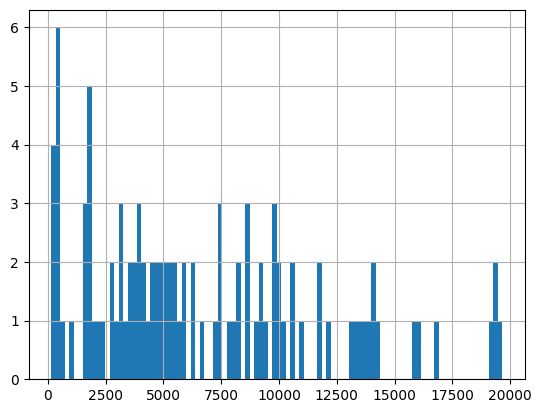

In [18]:
df_train.cnt_sent.hist(bins=100)

In [19]:
df_test.cnt_sent

0       772
1      5189
2      6597
3      2974
4      4395
5      1154
6       935
7       237
8       884
9      4927
10     6714
11     5091
12    14316
13     7536
14     1678
15     3568
17     3278
18     3136
19     5803
20    16724
21      922
22     4754
23     6194
24     2100
25     5835
26     6628
27     6038
28      142
29     3667
30      360
31     2900
32     5124
33      522
34     8139
35     4604
36     4158
37     2122
38      172
39     5068
40      440
41      271
42     3812
43    11867
44     2093
45    12456
46     9789
47    13078
48     9751
49     9301
50    11011
Name: cnt_sent, dtype: int64

<Axes: >

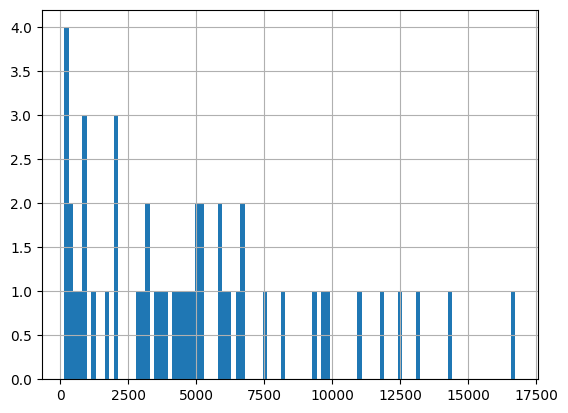

In [20]:
df_test.cnt_sent.hist(bins=100)

In [21]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   author              100 non-null    object 
 1   text_               100 non-null    object 
 2   cnt_sent            100 non-null    int64  
 3   text_len            100 non-null    int64  
 4   text                100 non-null    object 
 5   text_len2           100 non-null    int64  
 6   words_cnt           100 non-null    int64  
 7   wrds_sent_cnt       100 non-null    float64
 8   cnt_words_unique    100 non-null    int64  
 9   unwords_words       100 non-null    float64
 10  median_word_length  100 non-null    float64
 11  mean_word_length    100 non-null    float64
 12  max_word_length     100 non-null    int64  
 13  words_symbols       100 non-null    float64
 14  words_dots          100 non-null    float64
 15  words_commas        100 non-null    float64
 16  words_exc

In [22]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, 0 to 50
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   author              50 non-null     object 
 1   text_               50 non-null     object 
 2   cnt_sent            50 non-null     int64  
 3   text_len            50 non-null     int64  
 4   text                50 non-null     object 
 5   text_len2           50 non-null     int64  
 6   words_cnt           50 non-null     int64  
 7   wrds_sent_cnt       50 non-null     float64
 8   cnt_words_unique    50 non-null     int64  
 9   unwords_words       50 non-null     float64
 10  median_word_length  50 non-null     float64
 11  mean_word_length    50 non-null     float64
 12  max_word_length     50 non-null     int64  
 13  words_symbols       50 non-null     float64
 14  words_dots          50 non-null     float64
 15  words_commas        50 non-null     float64
 16  words_excls    

Итак, в этом ноутбуке будем мучать catboost с различными для него фичами. Попробуем перебить наш бейзлайн с логистической регрессией.

In [23]:
X_train = df_train['text']
y_train = df_train['author']
X_test = df_test['text']
y_test = df_test['author']

In [24]:
y_train

0      William_Shakespeare
1         William_Faulkner
2           Virginia_Woolf
3              Victor_Hugo
4         Ursula_K_Le_Guin
              ...         
95           Aldous_Huxley
96            Albert_Camus
97    Ahmet_Hamdi_Tanpinar
98         Agatha_Christie
99                   Aesop
Name: author, Length: 100, dtype: object

In [25]:
X_train

0     THE LIFE AND DEATH OF KING RICHARD III by Will...
1     Absalom Absalom William Faulkner —— From a lit...
2     NIGHT AND DAY By Virginia Woolf TO VANESSA BEL...
3     LES MISÉRABLES By Victor Hugo Translated by Is...
4     Rocannons world by Ursula K Le Guin Prologue H...
                            ...                        
95    CROME YELLOW By Aldous Huxley CHAPTER I Along ...
96    The Stranger By Albert Camus PART ONE I Mother...
97    Table of Contents Title Page Part I İhsan I II...
98     THE SECRET ADVERSARY By Agatha Christie TO AL...
99    THE ÆSOP FOR CHILDREN Illustration THE COCK AN...
Name: text, Length: 100, dtype: object

In [26]:
y_train

0      William_Shakespeare
1         William_Faulkner
2           Virginia_Woolf
3              Victor_Hugo
4         Ursula_K_Le_Guin
              ...         
95           Aldous_Huxley
96            Albert_Camus
97    Ahmet_Hamdi_Tanpinar
98         Agatha_Christie
99                   Aesop
Name: author, Length: 100, dtype: object

In [27]:
# 1. Вспомним Random baseline, но посчитаем по нему все метрики
random_baseline = DummyClassifier(strategy='uniform', random_state=42)
random_baseline.fit(X_train, y_train)
random_preds = random_baseline.predict(X_test)

random_acc = accuracy_score(y_test, random_preds)
precision_macro = precision_score(y_test, random_preds, average='macro', zero_division=0)
recall_macro = recall_score(y_test, random_preds, average='macro', zero_division=0)
f1_macro = f1_score(y_test, random_preds, average='macro', zero_division=0)
precision_micro = precision_score(y_test, random_preds, average='micro', zero_division=0)
recall_micro = recall_score(y_test, random_preds, average='micro', zero_division=0)
f1_micro = f1_score(y_test, random_preds, average='micro', zero_division=0)

In [28]:
df_metrics = pd.DataFrame(
    {
        "random_model": [
            random_acc,
            precision_macro,
            recall_macro,
            f1_macro,
            precision_micro,
            recall_micro,
            f1_micro,
        ]
    },
    index=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "precision_micro",
        "recall_micro",
        "f1_micro",
    ],
)
df_metrics

,random_model
accuracy,0.020000
precision_macro,0.014493
recall_macro,0.014493
f1_macro,0.014493
precision_micro,0.020000
recall_micro,0.020000
f1_micro,0.020000


Слабовато. Дальше очередь за катбустом и BoW

In [41]:
%%time
# 2. Simple Lexicon-based Catboost with BoW on cpu
bow_catboost = make_pipeline(
    CountVectorizer(max_features=500),
    CatBoostClassifier(random_state=42, verbose=0)
)
bow_catboost.fit(X_train, y_train)
bow_preds = bow_catboost.predict(X_test)

bow_acc = accuracy_score(y_test, bow_preds)
bow_precision_macro = precision_score(y_test, bow_preds, average='macro', zero_division=0)
bow_recall_macro = recall_score(y_test, bow_preds, average='macro', zero_division=0)
bow_f1_macro = f1_score(y_test, bow_preds, average='macro', zero_division=0)
bow_precision_micro = precision_score(y_test, bow_preds, average='micro', zero_division=0)
bow_recall_micro = recall_score(y_test, bow_preds, average='micro', zero_division=0)
bow_f1_micro = f1_score(y_test, bow_preds, average='micro', zero_division=0)

CPU times: user 1h 8min 25s, sys: 6.78 s, total: 1h 8min 32s
Wall time: 17min 55s


In [42]:
df_metrics["catboost_bow_cpu"] = [
    bow_acc,
    bow_precision_macro,
    bow_recall_macro,
    bow_f1_macro,
    bow_precision_micro,
    bow_recall_micro,
    bow_f1_micro,
]
df_metrics

,random_model,catboost_bow_cpu
accuracy,0.020000,0.540000
precision_macro,0.014493,0.422222
recall_macro,0.014493,0.450000
f1_macro,0.014493,0.430556
precision_micro,0.020000,0.540000
recall_micro,0.020000,0.540000
f1_micro,0.020000,0.540000


Уже значительно лучше. Но 17 минут - ооочень долго.

In [30]:
%%time
# 3. Обучение CatBoost с BoW на GPU
bow_catboost_gpu = make_pipeline(
    CountVectorizer(max_features=500),
    CatBoostClassifier(random_state=42, verbose=0, task_type="GPU")
)
bow_catboost_gpu.fit(X_train, y_train)
bow_preds_gpu = bow_catboost_gpu.predict(X_test)

bow_acc_gpu = accuracy_score(y_test, bow_preds_gpu)
bow_precision_macro_gpu = precision_score(y_test, bow_preds_gpu, average='macro', zero_division=0)
bow_recall_macro_gpu = recall_score(y_test, bow_preds_gpu, average='macro', zero_division=0)
bow_f1_macro_gpu = f1_score(y_test, bow_preds_gpu, average='macro', zero_division=0)
bow_precision_micro_gpu = precision_score(y_test, bow_preds_gpu, average='micro', zero_division=0)
bow_recall_micro_gpu = recall_score(y_test, bow_preds_gpu, average='micro', zero_division=0)
bow_f1_micro_gpu = f1_score(y_test, bow_preds_gpu, average='micro', zero_division=0)

CPU times: user 1min 58s, sys: 27 s, total: 2min 25s
Wall time: 1min 22s


Ого. В 15 раз быстрее! Проверим метрики

In [31]:
df_metrics["catboost_bow_gpu"] = [
    bow_acc_gpu,
    bow_precision_macro_gpu,
    bow_recall_macro_gpu,
    bow_f1_macro_gpu,
    bow_precision_micro_gpu,
    bow_recall_micro_gpu,
    bow_f1_micro_gpu,
]
df_metrics

,random_model,catboost_bow_cpu,catboost_bow_gpu
accuracy,0.020000,0.540000,0.500000
precision_macro,0.014493,0.422222,0.365179
recall_macro,0.014493,0.450000,0.446429
f1_macro,0.014493,0.430556,0.388095
precision_micro,0.020000,0.540000,0.500000
recall_micro,0.020000,0.540000,0.500000
f1_micro,0.020000,0.540000,0.500000


Метрики чуть хуже, но не в 15 раз)  
Давайте теперь попробуем нормализовать данные как в прошлый раз с логистической регрессией. Посмотрим, будет ли импакт.

In [32]:
%%time
# 3. Обучение CatBoost с BoW на GPU с нормализацией
bow_catboost_gpu = make_pipeline(
    CountVectorizer(max_features=500),
    Normalizer(),
    CatBoostClassifier(random_state=42, verbose=0, task_type="GPU")
)
bow_catboost_gpu.fit(X_train, y_train)
bow_preds_gpu = bow_catboost_gpu.predict(X_test)

bow_acc = accuracy_score(y_test, bow_preds_gpu)
bow_precision_macro = precision_score(y_test, bow_preds_gpu, average='macro', zero_division=0)
bow_recall_macro = recall_score(y_test, bow_preds_gpu, average='macro', zero_division=0)
bow_f1_macro = f1_score(y_test, bow_preds_gpu, average='macro', zero_division=0)
bow_precision_micro = precision_score(y_test, bow_preds_gpu, average='micro', zero_division=0)
bow_recall_micro = recall_score(y_test, bow_preds_gpu, average='micro', zero_division=0)
bow_f1_micro = f1_score(y_test, bow_preds_gpu, average='micro', zero_division=0)

CPU times: user 1min 55s, sys: 31.7 s, total: 2min 27s
Wall time: 1min 15s


In [33]:
df_metrics["catboost_bow_gpu_norm"] = [
    bow_acc,
    bow_precision_macro,
    bow_recall_macro,
    bow_f1_macro,
    bow_precision_micro,
    bow_recall_micro,
    bow_f1_micro,
]
df_metrics

,random_model,catboost_bow_cpu,catboost_bow_gpu,catboost_bow_gpu_norm
accuracy,0.020000,0.540000,0.500000,0.340000
precision_macro,0.014493,0.422222,0.365179,0.226562
recall_macro,0.014493,0.450000,0.446429,0.265625
f1_macro,0.014493,0.430556,0.388095,0.239583
precision_micro,0.020000,0.540000,0.500000,0.340000
recall_micro,0.020000,0.540000,0.500000,0.340000
f1_micro,0.020000,0.540000,0.500000,0.340000


Импакт сильно отрицательный. Наверное, нормализация действительно разрушает полезную информацию из countvectorizer, возможно из-за разреженности матрицы данных. Попробуем тогда tf-idf сразу со стандартизацией.

In [34]:
%%time
# 4. Обучение CatBoost с tfidf на GPU со стандартизацией
tfidf_catboost_gpu = make_pipeline(
    TfidfVectorizer(max_features=500),
    StandardScaler(with_mean=False),
    CatBoostClassifier(random_state=42, verbose=0, task_type="GPU")
)
tfidf_catboost_gpu.fit(X_train, y_train)
tfidf_preds_gpu = tfidf_catboost_gpu.predict(X_test)

tfidf_acc_gpu = accuracy_score(y_test, tfidf_preds_gpu)
tfidf_precision_macro_gpu = precision_score(y_test, tfidf_preds_gpu, average='macro', zero_division=0)
tfidf_recall_macro_gpu = recall_score(y_test, tfidf_preds_gpu, average='macro', zero_division=0)
tfidf_f1_macro_gpu = f1_score(y_test, tfidf_preds_gpu, average='macro', zero_division=0)
tfidf_precision_micro_gpu = precision_score(y_test, tfidf_preds_gpu, average='micro', zero_division=0)
tfidf_recall_micro_gpu = recall_score(y_test, tfidf_preds_gpu, average='micro', zero_division=0)
tfidf_f1_micro_gpu = f1_score(y_test, tfidf_preds_gpu, average='micro', zero_division=0)

CPU times: user 1min 55s, sys: 31.6 s, total: 2min 26s
Wall time: 1min 15s


In [35]:
df_metrics["catboost_tfidf_gpu"] = [
    tfidf_acc_gpu,
    tfidf_precision_macro_gpu,
    tfidf_recall_macro_gpu,
    tfidf_f1_macro_gpu,
    tfidf_precision_micro_gpu,
    tfidf_recall_micro_gpu,
    tfidf_f1_micro_gpu,
]
df_metrics

,random_model,catboost_bow_cpu,catboost_bow_gpu,catboost_bow_gpu_norm,catboost_tfidf_gpu
accuracy,0.020000,0.540000,0.500000,0.340000,0.380000
precision_macro,0.014493,0.422222,0.365179,0.226562,0.262295
recall_macro,0.014493,0.450000,0.446429,0.265625,0.311475
f1_macro,0.014493,0.430556,0.388095,0.239583,0.278689
precision_micro,0.020000,0.540000,0.500000,0.340000,0.380000
recall_micro,0.020000,0.540000,0.500000,0.340000,0.380000
f1_micro,0.020000,0.540000,0.500000,0.340000,0.380000


Неожиданно слабо. Подкинем еще фичей

In [36]:
%%time
# 5. Обучение CatBoost с tfidf (много фичей) на GPU со стандартизацией
tfidf_catboost_gpu = make_pipeline(
    TfidfVectorizer(max_features=10000),
    StandardScaler(with_mean=False),
    CatBoostClassifier(random_state=42, verbose=0, task_type="GPU")
)
tfidf_catboost_gpu.fit(X_train, y_train)
tfidf_preds_gpu = tfidf_catboost_gpu.predict(X_test)

tfidf_acc_gpu = accuracy_score(y_test, tfidf_preds_gpu)
tfidf_precision_macro_gpu = precision_score(y_test, tfidf_preds_gpu, average='macro', zero_division=0)
tfidf_recall_macro_gpu = recall_score(y_test, tfidf_preds_gpu, average='macro', zero_division=0)
tfidf_f1_macro_gpu = f1_score(y_test, tfidf_preds_gpu, average='macro', zero_division=0)
tfidf_precision_micro_gpu = precision_score(y_test, tfidf_preds_gpu, average='micro', zero_division=0)
tfidf_recall_micro_gpu = recall_score(y_test, tfidf_preds_gpu, average='micro', zero_division=0)
tfidf_f1_micro_gpu = f1_score(y_test, tfidf_preds_gpu, average='micro', zero_division=0)

CPU times: user 9min 21s, sys: 1min 53s, total: 11min 15s
Wall time: 7min 40s


Уух. Видеокарта прогрелась до 15гб из доступных 16-ти!

In [37]:
df_metrics["catboost_tfidf_gpu"] = [
    tfidf_acc_gpu,
    tfidf_precision_macro_gpu,
    tfidf_recall_macro_gpu,
    tfidf_f1_macro_gpu,
    tfidf_precision_micro_gpu,
    tfidf_recall_micro_gpu,
    tfidf_f1_micro_gpu,
]
df_metrics

,random_model,catboost_bow_cpu,catboost_bow_gpu,catboost_bow_gpu_norm,catboost_tfidf_gpu
accuracy,0.020000,0.540000,0.500000,0.340000,0.520000
precision_macro,0.014493,0.422222,0.365179,0.226562,0.421053
recall_macro,0.014493,0.450000,0.446429,0.265625,0.456140
f1_macro,0.014493,0.430556,0.388095,0.239583,0.432749
precision_micro,0.020000,0.540000,0.500000,0.340000,0.520000
recall_micro,0.020000,0.540000,0.500000,0.340000,0.520000
f1_micro,0.020000,0.540000,0.500000,0.340000,0.520000


С 10000 получилось лучше чем с 500-стами.

In [38]:
%%time
# 6. Попробуем N-grams + Catboost
ngram_catboost_gpu = make_pipeline(
    CountVectorizer(ngram_range=(1, 2), max_features=500),
    CatBoostClassifier(random_state=42, verbose=0, task_type="GPU")
)
ngram_catboost_gpu.fit(X_train, y_train)
ngram_preds_gpu = ngram_catboost_gpu.predict(X_test)

ngram_acc_gpu = accuracy_score(y_test, ngram_preds_gpu)
ngram_precision_macro_gpu = precision_score(y_test, ngram_preds_gpu, average='macro', zero_division=0)
ngram_recall_macro_gpu = recall_score(y_test, ngram_preds_gpu, average='macro', zero_division=0)
ngram_f1_macro_gpu = f1_score(y_test, ngram_preds_gpu, average='macro', zero_division=0)
ngram_precision_micro_gpu = precision_score(y_test, ngram_preds_gpu, average='micro', zero_division=0)
ngram_recall_micro_gpu = recall_score(y_test, ngram_preds_gpu, average='micro', zero_division=0)
ngram_f1_micro_gpu = f1_score(y_test, ngram_preds_gpu, average='micro', zero_division=0)

CPU times: user 2min 13s, sys: 29.1 s, total: 2min 42s
Wall time: 1min 36s


In [39]:
df_metrics["catboost_ngram_gpu"] = [
    ngram_acc_gpu,
    ngram_precision_macro_gpu,
    ngram_recall_macro_gpu,
    ngram_f1_macro_gpu,
    ngram_precision_micro_gpu,
    ngram_recall_micro_gpu,
    ngram_f1_micro_gpu,
]
df_metrics

,random_model,catboost_bow_cpu,catboost_bow_gpu,catboost_bow_gpu_norm,catboost_tfidf_gpu,catboost_ngram_gpu
accuracy,0.020000,0.540000,0.500000,0.340000,0.520000,0.480000
precision_macro,0.014493,0.422222,0.365179,0.226562,0.421053,0.370690
recall_macro,0.014493,0.450000,0.446429,0.265625,0.456140,0.413793
f1_macro,0.014493,0.430556,0.388095,0.239583,0.432749,0.385057
precision_micro,0.020000,0.540000,0.500000,0.340000,0.520000,0.480000
recall_micro,0.020000,0.540000,0.500000,0.340000,0.520000,0.480000
f1_micro,0.020000,0.540000,0.500000,0.340000,0.520000,0.480000


In [40]:
# 7. Word2Vec Embeddings + Catboost
from sklearn.base import TransformerMixin
from gensim.models import Word2Vec

class EmbeddingTransformer(TransformerMixin):
    """Custom transformer to generate embeddings for texts using Word2Vec."""
    def __init__(self, vector_size=100, window=5, min_count=1, sg=0):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.sg = sg
        self.model = None

    def fit(self, X, y=None):
        tokenized_texts = [text.split() for text in X]
        self.model = Word2Vec(
            sentences=tokenized_texts, 
            vector_size=self.vector_size, 
            window=self.window, 
            min_count=self.min_count, 
            sg=self.sg
        )
        return self

    def transform(self, X):
        tokenized_texts = [text.split() for text in X]
        embeddings = [
            np.mean([self.model.wv[word] for word in text if word in self.model.wv]
                    or [np.zeros(self.vector_size)], axis=0)
            for text in tokenized_texts
        ]
        return np.array(embeddings)

word2vec_catboost_gpu = make_pipeline(
    EmbeddingTransformer(vector_size=100, window=5, min_count=1, sg=1),
    CatBoostClassifier(random_state=42, verbose=0, task_type="GPU")
)

word2vec_catboost_gpu.fit(X_train, y_train)
word2vec_preds_gpu = word2vec_catboost_gpu.predict(X_test)

word2vec_acc_gpu = accuracy_score(y_test, word2vec_preds_gpu)
word2vec_precision_macro_gpu = precision_score(y_test, word2vec_preds_gpu, average='macro', zero_division=0)
word2vec_recall_macro_gpu = recall_score(y_test, word2vec_preds_gpu, average='macro', zero_division=0)
word2vec_f1_macro_gpu = f1_score(y_test, word2vec_preds_gpu, average='macro', zero_division=0)
word2vec_precision_micro_gpu = precision_score(y_test, word2vec_preds_gpu, average='micro', zero_division=0)
word2vec_recall_micro_gpu = recall_score(y_test, word2vec_preds_gpu, average='micro', zero_division=0)
word2vec_f1_micro_gpu = f1_score(y_test, word2vec_preds_gpu, average='micro', zero_division=0)

In [41]:
df_metrics["catboost_word2vec_gpu"] = [
    word2vec_acc_gpu,
    word2vec_precision_macro_gpu,
    word2vec_recall_macro_gpu,
    word2vec_f1_macro_gpu,
    word2vec_precision_micro_gpu,
    word2vec_recall_micro_gpu,
    word2vec_f1_micro_gpu,
]
df_metrics

,random_model,catboost_bow_cpu,catboost_bow_gpu,catboost_bow_gpu_norm,catboost_tfidf_gpu,catboost_ngram_gpu,catboost_word2vec_gpu
accuracy,0.020000,0.540000,0.500000,0.340000,0.520000,0.480000,0.500000
precision_macro,0.014493,0.422222,0.365179,0.226562,0.421053,0.370690,0.401786
recall_macro,0.014493,0.450000,0.446429,0.265625,0.456140,0.413793,0.446429
f1_macro,0.014493,0.430556,0.388095,0.239583,0.432749,0.385057,0.416667
precision_micro,0.020000,0.540000,0.500000,0.340000,0.520000,0.480000,0.500000
recall_micro,0.020000,0.540000,0.500000,0.340000,0.520000,0.480000,0.500000
f1_micro,0.020000,0.540000,0.500000,0.340000,0.520000,0.480000,0.500000


Все еще не можем побить катбуст и BoW на cpu!

In [43]:
%%time
# 8. Еще попробуем tfidf без стандартизации но с нграммами и катбустом
tfidf_catboost_gpu = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    CatBoostClassifier(random_state=42, verbose=0, task_type="GPU")
)
tfidf_catboost_gpu.fit(X_train, y_train)
tfidf_preds_gpu = tfidf_catboost_gpu.predict(X_test)

tfidf_acc_gpu = accuracy_score(y_test, tfidf_preds_gpu)
tfidf_precision_macro_gpu = precision_score(y_test, tfidf_preds_gpu, average='macro', zero_division=0)
tfidf_recall_macro_gpu = recall_score(y_test, tfidf_preds_gpu, average='macro', zero_division=0)
tfidf_f1_macro_gpu = f1_score(y_test, tfidf_preds_gpu, average='macro', zero_division=0)
tfidf_precision_micro_gpu = precision_score(y_test, tfidf_preds_gpu, average='micro', zero_division=0)
tfidf_recall_micro_gpu = recall_score(y_test, tfidf_preds_gpu, average='micro', zero_division=0)
tfidf_f1_micro_gpu = f1_score(y_test, tfidf_preds_gpu, average='micro', zero_division=0)

CPU times: user 7min 59s, sys: 1min 39s, total: 9min 39s
Wall time: 6min 30s


In [44]:
df_metrics["catboost_tfidf_gpu"] = [
    tfidf_acc_gpu,
    tfidf_precision_macro_gpu,
    tfidf_recall_macro_gpu,
    tfidf_f1_macro_gpu,
    tfidf_precision_micro_gpu,
    tfidf_recall_micro_gpu,
    tfidf_f1_micro_gpu,
]
df_metrics

,random_model,catboost_bow_cpu,catboost_bow_gpu,catboost_bow_gpu_norm,catboost_tfidf_gpu,catboost_ngram_gpu,catboost_word2vec_gpu
accuracy,0.020000,0.540000,0.500000,0.340000,0.440000,0.480000,0.500000
precision_macro,0.014493,0.422222,0.365179,0.226562,0.315789,0.370690,0.401786
recall_macro,0.014493,0.450000,0.446429,0.265625,0.385965,0.413793,0.446429
f1_macro,0.014493,0.430556,0.388095,0.239583,0.336257,0.385057,0.416667
precision_micro,0.020000,0.540000,0.500000,0.340000,0.440000,0.480000,0.500000
recall_micro,0.020000,0.540000,0.500000,0.340000,0.440000,0.480000,0.500000
f1_micro,0.020000,0.540000,0.500000,0.340000,0.440000,0.480000,0.500000


In [47]:
%%time
# 9. И напоследок попробуем bow (хорошая была модель) и катбустом с небольшой защитой от переобучения и регуляризацией
bow_catboost_gpu = make_pipeline(
    CountVectorizer(max_features=500),
    CatBoostClassifier(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        l2_leaf_reg=10,
        boosting_type="Plain",
        auto_class_weights="Balanced",
        eval_metric="MultiClass",
        early_stopping_rounds=50,
        task_type="GPU",
        verbose=0
    )
)
bow_catboost_gpu.fit(X_train, y_train)
bow_preds_gpu = bow_catboost_gpu.predict(X_test)

bow_acc_gpu = accuracy_score(y_test, bow_preds_gpu)
bow_precision_macro_gpu = precision_score(y_test, bow_preds_gpu, average='macro', zero_division=0)
bow_recall_macro_gpu = recall_score(y_test, bow_preds_gpu, average='macro', zero_division=0)
bow_f1_macro_gpu = f1_score(y_test, bow_preds_gpu, average='macro', zero_division=0)
bow_precision_micro_gpu = precision_score(y_test, bow_preds_gpu, average='micro', zero_division=0)
bow_recall_micro_gpu = recall_score(y_test, bow_preds_gpu, average='micro', zero_division=0)
bow_f1_micro_gpu = f1_score(y_test, bow_preds_gpu, average='micro', zero_division=0)

CPU times: user 1min 45s, sys: 27.9 s, total: 2min 13s
Wall time: 1min 8s


In [48]:
df_metrics["catboost_bow_gpu_params"] = [
    bow_acc_gpu,
    bow_precision_macro_gpu,
    bow_recall_macro_gpu,
    bow_f1_macro_gpu,
    bow_precision_micro_gpu,
    bow_recall_micro_gpu,
    bow_f1_micro_gpu,
]
df_metrics

,random_model,catboost_bow_cpu,catboost_bow_gpu,catboost_bow_gpu_norm,catboost_tfidf_gpu,catboost_ngram_gpu,catboost_word2vec_gpu,catboost_bow_gpu_params
accuracy,0.020000,0.540000,0.500000,0.340000,0.440000,0.480000,0.500000,0.500000
precision_macro,0.014493,0.422222,0.365179,0.226562,0.315789,0.370690,0.401786,0.387931
recall_macro,0.014493,0.450000,0.446429,0.265625,0.385965,0.413793,0.446429,0.431034
f1_macro,0.014493,0.430556,0.388095,0.239583,0.336257,0.385057,0.416667,0.402299
precision_micro,0.020000,0.540000,0.500000,0.340000,0.440000,0.480000,0.500000,0.500000
recall_micro,0.020000,0.540000,0.500000,0.340000,0.440000,0.480000,0.500000,0.500000
f1_micro,0.020000,0.540000,0.500000,0.340000,0.440000,0.480000,0.500000,0.500000


Метрики почти не изменились. Что ж. Попробуем сблендить пару моделей.

In [55]:
%%time
# 10. Последняя попытка. Блендинг!
from sklearn.ensemble import VotingClassifier

# TF-IDF + CatBoost
tfidf_catboost_gpu = make_pipeline(
    TfidfVectorizer(max_features=1000, ngram_range=(1, 2)),
    CatBoostClassifier(random_state=42, verbose=0, task_type="GPU")
)
tfidf_catboost_gpu.fit(X_train, y_train)

# BoW + CatBoost
bow_catboost_gpu = make_pipeline(
    CountVectorizer(max_features=1000),
    CatBoostClassifier(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        l2_leaf_reg=10,
        boosting_type="Plain",
        auto_class_weights="Balanced",
        eval_metric="MultiClass",
        early_stopping_rounds=50,
        task_type="GPU",
        verbose=0
    )
)
bow_catboost_gpu.fit(X_train, y_train)

tfidf_proba = tfidf_catboost_gpu.predict_proba(X_test)
bow_proba = bow_catboost_gpu.predict_proba(X_test)

blended_proba = (tfidf_proba + bow_proba) / 2
blended_preds = np.argmax(blended_proba, axis=1)

class_labels = tfidf_catboost_gpu.named_steps["catboostclassifier"].classes_
blended_preds = np.array([class_labels[i] for i in blended_preds])

voting_acc = accuracy_score(y_test, blended_preds)
voting_precision_macro = precision_score(y_test, blended_preds, average='macro', zero_division=0)
voting_recall_macro = recall_score(y_test, blended_preds, average='macro', zero_division=0)
voting_f1_macro = f1_score(y_test, blended_preds, average='macro', zero_division=0)
voting_precision_micro = precision_score(y_test, blended_preds, average='micro', zero_division=0)
voting_recall_micro = recall_score(y_test, blended_preds, average='micro', zero_division=0)
voting_f1_micro = f1_score(y_test, blended_preds, average='micro', zero_division=0)

CPU times: user 5min 24s, sys: 1min 23s, total: 6min 48s
Wall time: 3min 52s


In [57]:
df_metrics["catboost_voting_gpu"] = [
    voting_acc,
    voting_precision_macro,
    voting_recall_macro,
    voting_f1_macro,
    voting_precision_micro,
    voting_recall_micro,
    voting_f1_micro,
]
df_metrics_rounded = df_metrics.round(3)
df_metrics_rounded

,random_model,catboost_bow_cpu,catboost_bow_gpu,catboost_bow_gpu_norm,catboost_tfidf_gpu,catboost_ngram_gpu,catboost_word2vec_gpu,catboost_bow_gpu_params,catboost_voting_gpu
accuracy,0.020,0.540,0.500,0.340,0.440,0.480,0.500,0.500,0.400
precision_macro,0.014,0.422,0.365,0.227,0.316,0.371,0.402,0.388,0.294
recall_macro,0.014,0.450,0.446,0.266,0.386,0.414,0.446,0.431,0.339
f1_macro,0.014,0.431,0.388,0.240,0.336,0.385,0.417,0.402,0.308
precision_micro,0.020,0.540,0.500,0.340,0.440,0.480,0.500,0.500,0.400
recall_micro,0.020,0.540,0.500,0.340,0.440,0.480,0.500,0.500,0.400
f1_micro,0.020,0.540,0.500,0.340,0.440,0.480,0.500,0.500,0.400


Ох. Метрики блендинга ухудшились.  
Выводы: бывают задачи, где не бустинг всему голова, ибо в бейзлайне на том же датасете я получал accuracy 0.7 с обычной логистической регрессией, да еще и без gpu, да еще и обучается логрег в момент! Или, как вариант, если датасет будет в 10-100 раз побольше, тут уже бустинги покажут себя во всей красе!